In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.linear_model import LinearRegression, Ridge
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

In [13]:
from matplotlib.font_manager import FontProperties
from matplotlib.font_manager import findfont

#sns.set_palette([  "#89A8F6","#0F42C6",'#C9CED5',  "#1C2029"])

sns.set_style('darkgrid',{
    "axes.facecolor": "#f0f0f0",
    "axes.linewidth": 1.5,
    'axes.grid': True,
    'axes.labelcolor': '#000',
    "font.size": 18,
    'axes.edgecolor': '#fff',
    'grid.color': '#9d9d9d',
    'text.color': '#000',
    'xtick.color': '#000'
})

In [14]:
def generate_test_data(n_samples=500):
    np.random.seed(42)

    D_values = [2, 5, 10, 15, 20]
    W_values = [10, 30, 100, 300, 1000]
    F_values = [0.3, 0.6, 0.95]
    approaches = ["A", "B", "C"]
    profiles = ["build_system", "file_manager", "web_server", "backup", "refactoring"]
    distributions = ["uniform", "zipf"]
    localities = [0.0, 0.8]
    zipf_s_values = [0.0, 1.0]

    profile_weights = {
        "build_system": [0.4, 0.3, 0.1, 0.1, 0.05, 0.05],
        "file_manager": [0.3, 0.2, 0.2, 0.2, 0.05, 0.05],
        "web_server": [0.8, 0.1, 0.0, 0.1, 0.0, 0.0],
        "backup": [0.1, 0.7, 0.0, 0.0, 0.2, 0.0],
        "refactoring": [0.1, 0.1, 0.1, 0.1, 0.5, 0.1],
    }

    data = []

    for _ in range(n_samples):
        D = np.random.choice(D_values)
        W = np.random.choice(W_values)
        F = np.random.choice(F_values)
        approach = np.random.choice(approaches)
        profile = np.random.choice(profiles)
        dist = np.random.choice(distributions)
        locality = np.random.choice(localities)
        zipf_s = np.random.choice(zipf_s_values)

        op_weights = profile_weights[profile]

        base_latency = (
            5.0 * np.log1p(D)
            + 2.0 * np.log1p(W)
            + 30.0 * F
            + 1.5 * np.log1p(D) * np.log1p(W)
        )

        op_costs = [1.0, 1.2, 1.5, 2.0, 5.0, 10.0]
        profile_factor = sum(w * c for w, c in zip(op_weights, op_costs))

        if dist == "zipf":
            dist_factor = 0.5 + 0.3 * zipf_s
        else:
            dist_factor = 1.0

        locality_factor = 1.0 - 0.3 * locality

        if approach == "A":
            approach_factor = 1.0
        elif approach == "B":
            approach_factor = 0.3
        else:
            approach_factor = 0.5

        latency = (
            base_latency
            * profile_factor
            * dist_factor
            * locality_factor
            * approach_factor
        )
        latency += np.random.normal(0, latency * 0.05)

        if op_weights[4] + op_weights[5] > 0.3:
            p99_multiplier = 3.0
        else:
            p99_multiplier = 1.5
        p99_latency = latency * p99_multiplier + np.random.normal(0, latency * 0.1)

        if approach == "A":
            memory = D * W * F * 80
        elif approach == "B":
            memory = D * W * F * 120
        else:
            memory = D * W * F * 180

        throughput = 1000000.0 / latency if latency > 0 else 1000

        data.append(
            {
                "D": D,
                "W": W,
                "F": F,
                "profile": profile,
                "system_t": approach,
                "dist": dist,
                "zipf_s": zipf_s,
                "locality": locality,
                "op_read": op_weights[0],
                "op_write": op_weights[1],
                "op_mkdir": op_weights[2],
                "op_ls": op_weights[3],
                "op_mv": op_weights[4],
                "op_find": op_weights[5],
                "avg_latency": latency,
                "p99_latency": p99_latency,
                "memory_bytes": memory,
                "throughput_ops_sec": throughput,
            }
        )

    return pd.DataFrame(data)

In [15]:
df = generate_test_data(1000)

In [16]:
df

,D,W,F,profile,system_t,dist,zipf_s,locality,op_read,op_write,op_mkdir,op_ls,op_mv,op_find,avg_latency,p99_latency,memory_bytes,throughput_ops_sec
0,15,1000,0.95,refactoring,C,uniform,1.0,0.0,0.1,0.1,0.1,0.1,0.50,0.10,175.209166,543.332653,2565000.0,5707.463949
1,10,1000,0.60,file_manager,B,zipf,0.0,0.8,0.3,0.2,0.2,0.2,0.05,0.05,16.714317,27.643333,720000.0,59828.946310
2,20,300,0.30,web_server,A,uniform,1.0,0.0,0.8,0.1,0.0,0.1,0.00,0.00,68.236560,101.236668,144000.0,14654.900461
3,10,300,0.95,web_server,A,uniform,0.0,0.0,0.8,0.1,0.0,0.1,0.00,0.00,78.688309,125.487707,228000.0,12708.368221
4,20,30,0.95,backup,C,uniform,0.0,0.8,0.1,0.7,0.0,0.0,0.20,0.00,47.912272,66.316476,102600.0,20871.479527
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5,100,0.95,backup,B,uniform,1.0,0.8,0.1,0.7,0.0,0.0,0.20,0.00,24.907525,32.156685,57000.0,40148.509529
996,15,300,0.30,file_manager,B,uniform,0.0,0.8,0.3,0.2,0.2,0.2,0.05,0.05,28.054444,41.446467,162000.0,35644.976352
997,15,10,0.60,build_system,A,uniform,1.0,0.8,0.4,0.3,0.1,0.1,0.05,0.05,64.946431,97.654196,7200.0,15397.305014
998,20,100,0.30,build_system,A,zipf,1.0,0.8,0.4,0.3,0.1,0.1,0.05,0.05,59.127416,87.195693,48000.0,16912.628066


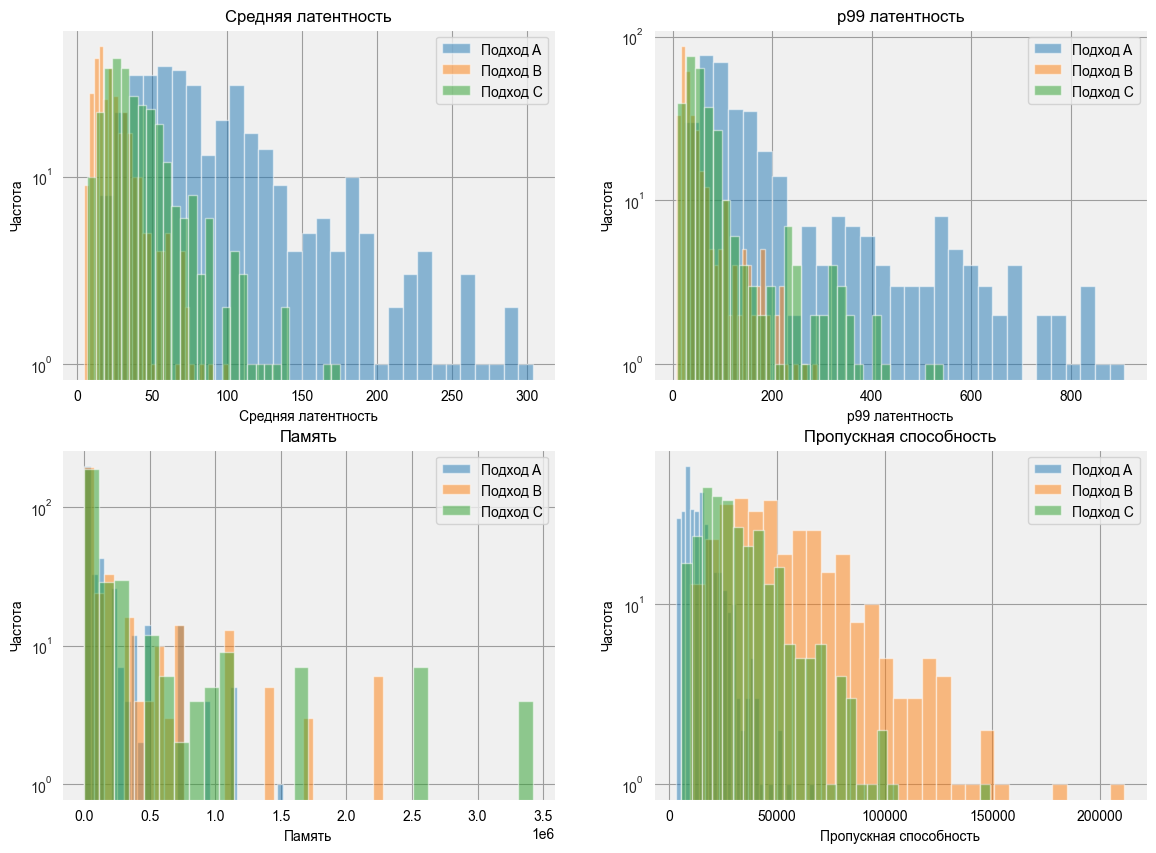

In [17]:
metrics = ['avg_latency', 'p99_latency', 'memory_bytes', 'throughput_ops_sec']
titles = ['Средняя латентность', 'p99 латентность', 'Память', 'Пропускная способность']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric, title in zip(axes.flat, metrics, titles):
    for approach in ['A','B','C']:
        subset = df[df['system_t']==approach][metric]
        ax.hist(subset, bins=30, alpha=0.5, label=f'Подход {approach}')
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel('Частота')
    ax.legend()
    ax.set_yscale('log')

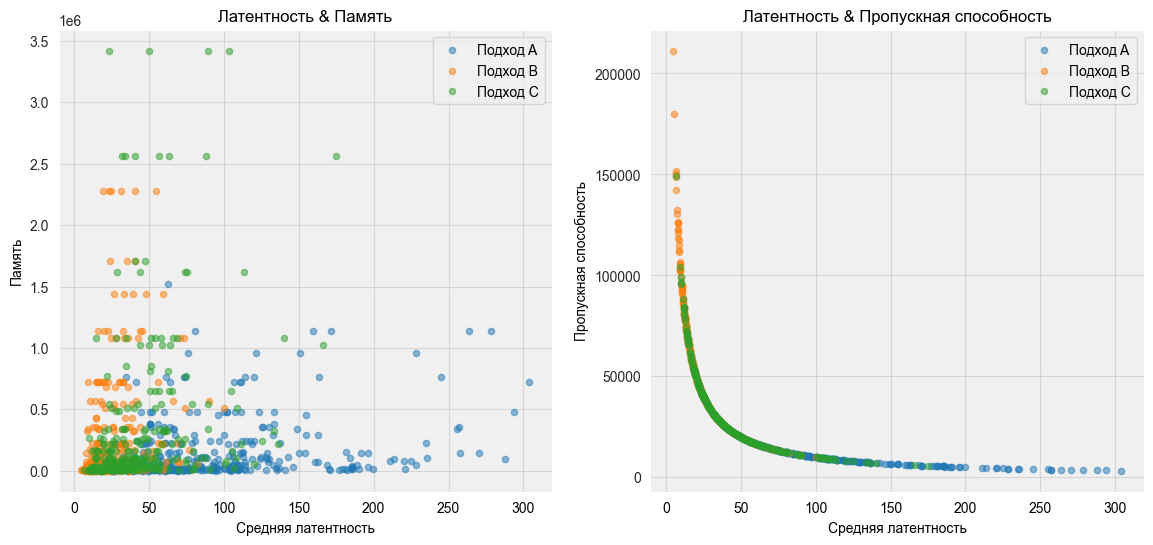

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for approach in ['A','B','C']:
    sub = df[df['system_t']==approach]
    axes[0].scatter(sub['avg_latency'], sub['memory_bytes'], alpha=0.5, s=20, label=f'Подход {approach}')
axes[0].set_xlabel('Средняя латентность')
axes[0].set_ylabel('Память')
axes[0].set_title('Латентность & Память')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for approach in ['A','B','C']:
    sub = df[df['system_t']==approach]
    axes[1].scatter(sub['avg_latency'], sub['throughput_ops_sec'], alpha=0.5, s=20, label=f'Подход {approach}')
axes[1].set_xlabel('Средняя латентность')
axes[1].set_ylabel('Пропускная способность')
axes[1].set_title('Латентность & Пропускная способность')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

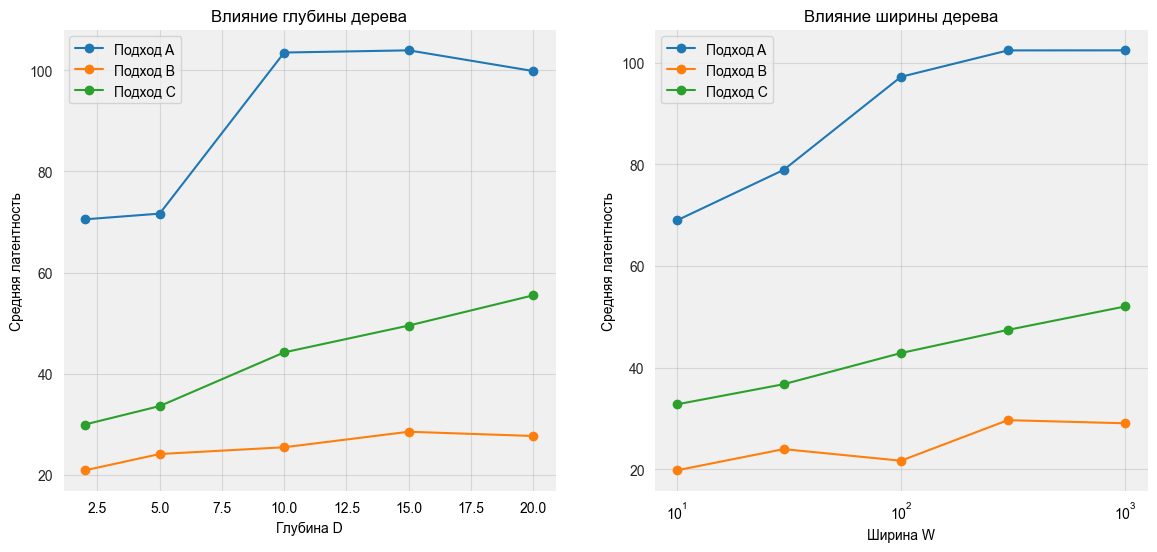

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for approach in ['A','B','C']:
    grouped = df[df['system_t']==approach].groupby('D')['avg_latency'].mean()
    axes[0].plot(grouped.index, grouped.values, marker='o', label=f'Подход {approach}')
axes[0].set_xlabel('Глубина D')
axes[0].set_ylabel('Средняя латентность')
axes[0].set_title('Влияние глубины дерева')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for approach in ['A','B','C']:
    grouped = df[df['system_t']==approach].groupby('W')['avg_latency'].mean()
    axes[1].plot(grouped.index, grouped.values, marker='o', label=f'Подход {approach}')
axes[1].set_xlabel('Ширина W')
axes[1].set_ylabel('Средняя латентность')
axes[1].set_title('Влияние ширины дерева')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale('log')

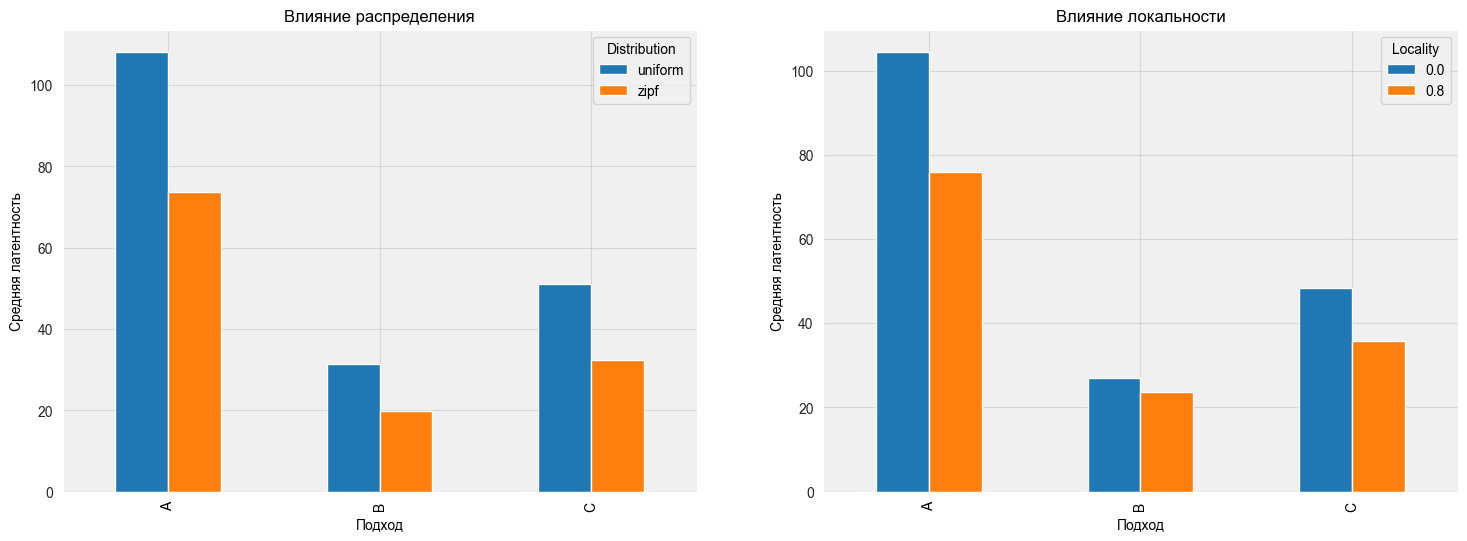

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

zipf_effect = df.groupby(['system_t','dist'])['avg_latency'].mean().unstack()
zipf_effect.plot(kind='bar', ax=axes[0])
axes[0].set_title('Влияние распределения')
axes[0].set_xlabel('Подход')
axes[0].set_ylabel('Средняя латентность')
axes[0].legend(title='Distribution')
axes[0].grid(True, alpha=0.3)

loc_effect = df.groupby(['system_t','locality'])['avg_latency'].mean().unstack()
loc_effect.plot(kind='bar', ax=axes[1])
axes[1].set_title('Влияние локальности')
axes[1].set_xlabel('Подход')
axes[1].set_ylabel('Средняя латентность')
axes[1].legend(title='Locality')
axes[1].grid(True, alpha=0.3)

Text(0.5, 1.0, 'Корреляционная матрица')

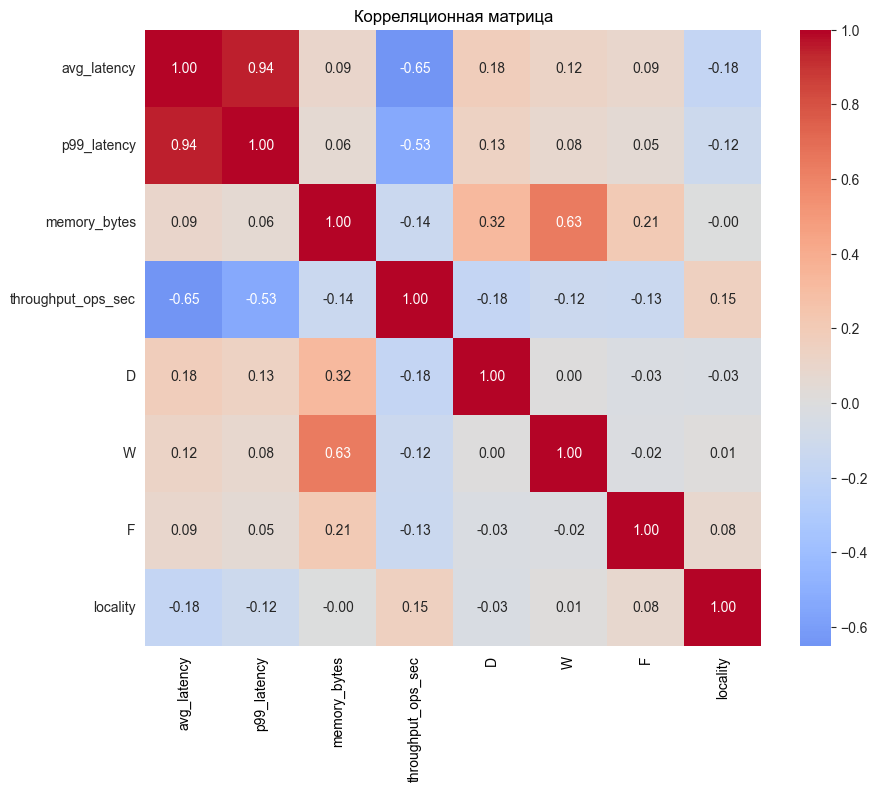

In [21]:
metric_cols = ['avg_latency','p99_latency','memory_bytes','throughput_ops_sec','D','W','F','locality']
corr = df[metric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Корреляционная матрица')

Коэффициент корреляции Пирсона между avg_latency и p99_latency: 0.945


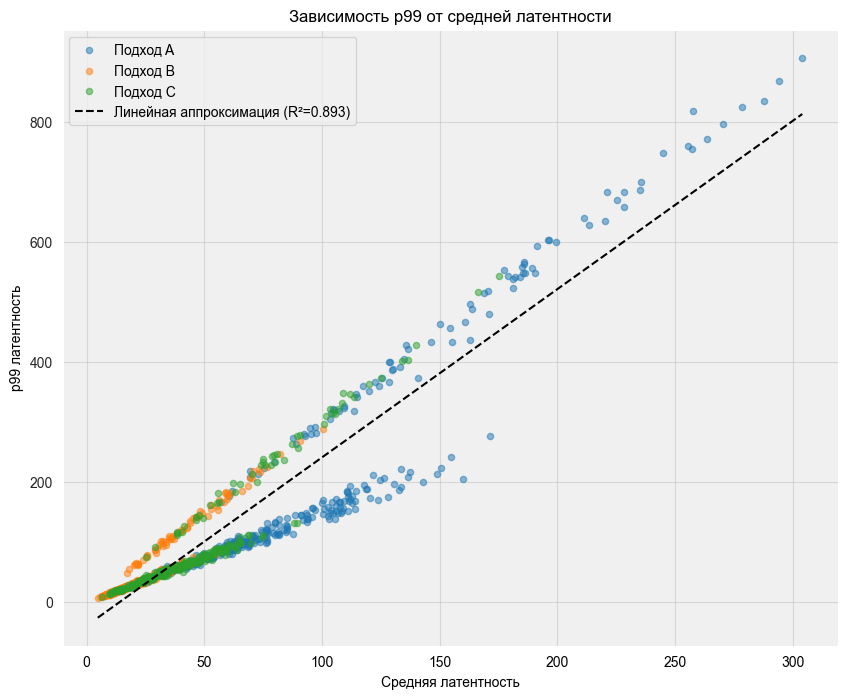

In [22]:
plt.figure(figsize=(10, 8))
for approach in ['A','B','C']:
    sub = df[df['system_t']==approach]
    plt.scatter(sub['avg_latency'], sub['p99_latency'], alpha=0.5, s=20, label=f'Подход {approach}')

coef = np.polyfit(df['avg_latency'], df['p99_latency'], 1)
p = np.poly1d(coef)
x_line = np.linspace(df['avg_latency'].min(), df['avg_latency'].max(), 100)
r2_lin = np.corrcoef(df['avg_latency'], df['p99_latency'])[0,1]**2
plt.plot(x_line, p(x_line), 'k--', label=f'Линейная аппроксимация (R²={r2_lin:.3f})')

plt.xlabel('Средняя латентность')
plt.ylabel('p99 латентность')
plt.title('Зависимость p99 от средней латентности')
plt.legend()
plt.grid(True, alpha=0.3)

print(f"Коэффициент корреляции Пирсона между avg_latency и p99_latency: {pearsonr(df['avg_latency'], df['p99_latency'])[0]:.3f}")